### Computational Guided Inquiry for PChem (Neshyba, 2026)


# Slicing Thermodynamic Surfaces

## Organization of the $P(T,V)$ state function and state space
In this exercise, we'll load in a 2-d grid of state-space temperatures and volumes, and the pressure as a function of that state space: $P(T,V)$. We'll explore how to "slice through" the pressure in the two dimensions (temperature and volume), and apply what we learned about graphing those slices, and taking their derivatives. 

First, when we say "load in", it means we'll instruct Python to open files "Pgrid.txt", "Tgrid.txt", and "Vgrid.txt", and copy the information in those files into Python variables. Here, those variables are called Pgrid, Tgrid, and Vgrid. 

You should also recognize that that information is a *discrete representation* of $P(T,V)$. Each combination of temperature and volume has a specific pair of indices -- so we can talk about the "ith" temperature and the "jth" volume. Connected to that idea is that in Python, indexing starts at *zero* (not one). 

## Terminology of Slicing: Isochores and Isotherms
In a temperature/volume state space, the vocabulary goes like this:

An *isochore* in ($T,V$) state space is a path that spans a range of temperatures, but all at the same volume. (Physically, we wouldn't recommend heating up gases in a confined volume, but in Python it's pretty safe.) To specify all these temperatures and the corresponding pressures, we can use Python's colon (":") indexing method. Specifically, ":" means "*all* of them." So for example, the temperatures and pressures belonging to the jth isochore would be the array of numbers 

    Tgrid[:,j]
    Pgrid[:,j]

An *isotherm* in ($T,V$) state space is a path in which the temperature stays constant, but the volume varies. You're enacting this physically when you pump up a bicycle tire, as long as you wait for the temperature to equilibrate with the surrounding air. The volumes and pressures belonging to the ith temperature would be the arrays 

    Vgrid[i,:]
    Pgrid[i,:]


What we've just described is *slicing*. 

Sometimes, we'd like to store slices as named variables. Below, for example, we're making new variables ("Tisochore2" and "Pisochore2") that will store the #2 isochore temperatures and pressures.

    Tisochore2 = Tgrid[:,2]
    Pisochore2 = Pgrid[:,2]

Once the slices are stored this way, we'll be set up to do similar operations, like plotting and taking derivatives. 

## Learning Goals
1. Explain what's meant by a *discrete representation* of a continuous variable.
1. Define the terms *isochore* and *isotherm*.
1. Extract and plot isochores & isotherms from gridded data (and their derivatives).

In [34]:
from pint import UnitRegistry; AssignQuantity = UnitRegistry().Quantity
import warnings; warnings.filterwarnings("ignore", "The unit of the quantity is stripped when downcasting to ndarray")
import numpy as np
import matplotlib.pyplot as plt; plt.rc("figure", figsize=(15, 12));plt.rcParams['font.size'] = 24
import sys; sys.path.append('/home'); import PchemLibrary as PL

### Loading gridded state-space variables and functions
The cell below uses numpy's "loadtxt" function to load the state space variables $T$ and $V$, from files. We'll be using these for all the work we'll be doing in this activity.

In [35]:
# Load the temperature data and attach units
Tgrid = np.loadtxt('Tgrid.txt')
Tgrid = AssignQuantity(Tgrid,'K')
print(np.shape(Tgrid))

# Load the volume data and attach units
Vgrid = np.loadtxt('Vgrid.txt')
Vgrid = AssignQuantity(Vgrid,'L')
print(np.shape(Vgrid))

(51, 42)
(51, 42)


### Your turn
Use numpy's "loadtxt" function to load the state function $P$ from the file "Pgrid.txt", and use AssignQuantity to attach units "atmosphere". Call the variable "Pgrid".

In [36]:
### BEGIN SOLUTION
Pgrid = np.loadtxt('Pgrid.txt')
Pgrid = AssignQuantity(Pgrid,'atm')
print(np.shape(Pgrid))
### END SOLUTION

(51, 42)


### Plotting in 3d
Use the cell below to make a 3d surface plot of the state function Pgrid that you just loaded, on the state space defined by Tgrid and Vgrid. Some reminders ... 

    # Prepping the axis labels
    xlabel = "T "+str(Tgrid.units)
    ylabel = ...
    zlabel = ...
    llist = [xlabel, ylabel, zlabel]

    # Graph the pressure
    PL.plot_surface1(Tgrid, Vgrid, Pgrid, color='blue',title='Pgrid.txt',labellist=llist).show() 

In [37]:
### BEGIN SOLUTION
# Prepping the axis labels
xlabel = "T "+str(Tgrid.units)
ylabel = "V "+str(Vgrid.units) 
zlabel = "P "+str(Pgrid.units)
llist = [xlabel, ylabel, zlabel]

# Graph the pressure
# ax = PL.plot_surface(Tgrid, Vgrid, Pgrid)
PL.plot_surface1(Tgrid, Vgrid, Pgrid, color='plum', title='Pgrid.txt',labellist=llist).show()
### END SOLUTION

### Storing and plotting isochores
The cell below slices out (creates) new variables containing pressure and temperature of the 0th *isochore* of $P(T,V)$, and plots one against the other.

Tisochore =  [200.0 204.0 208.0 212.0 216.0 220.0 224.0 228.0 232.0 236.0 240.0 244.0 248.0 252.0 256.0 260.0 264.0 268.0 272.0 276.0 280.0 284.0 288.0 292.0 296.0 300.0 304.0 308.0 312.0 316.0 320.0 324.0 328.0 332.0 336.0 340.0 344.0 348.0 352.0 356.0 360.0 364.0 368.0 372.0 376.0 380.0 384.0 388.0 392.0 396.0 400.0] kelvin
Visochore =  [1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0] liter
Pisochore =  [15.616644593434515 15.955723105831208 16.294801618227904 16.633880130624597 16.97295864302129 17.312037155417986 17.65111566781468 17.990194180211375 18.32927269260807 18.66835120500476 19.007429717401454 19.34650822979815 19.685586742194847 20.02466525459154 20.363743766988232 20.702822279384925 21.04190079178162 21.380979304178318 21.72005781657501 22.059136328971704 22.398214841368397 22.737293353765093 23.07637186616179 23.41

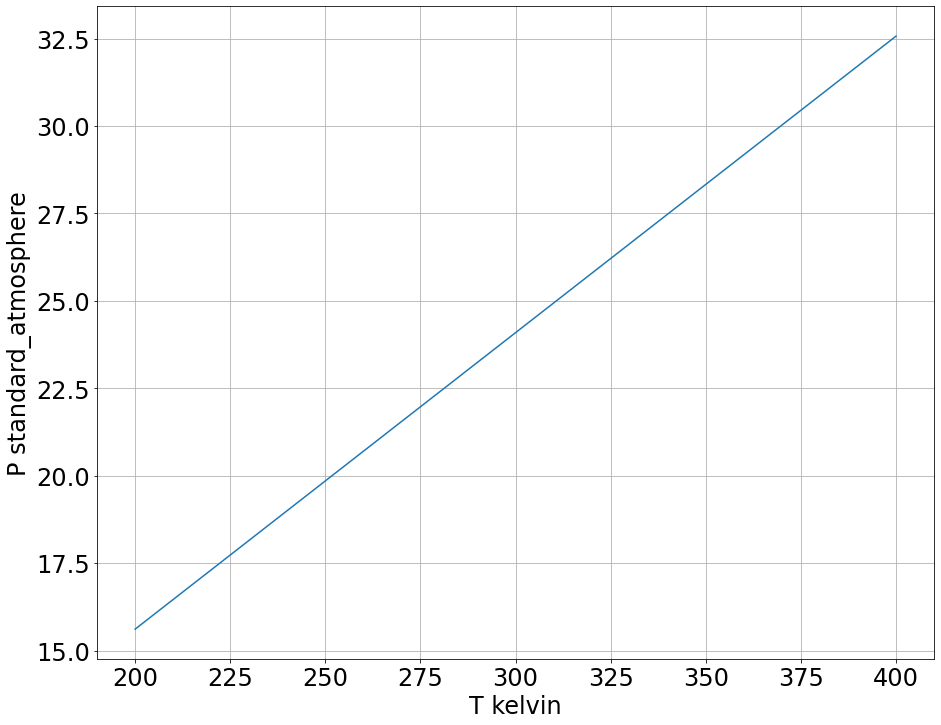

In [38]:
Tisochore0 = Tgrid[:,0]; print("Tisochore = ", Tisochore0)
Visochore0 = Vgrid[:,0]; print("Visochore = ", Visochore0) 
Pisochore0 = Pgrid[:,0]; print("Pisochore = ", Pisochore0) 

xlabel = "T "+str(Tisochore0.units)
ylabel = "P "+str(Pisochore0.units)

plt.figure()
plt.plot(Tisochore0,Pisochore0)
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.grid(True)

### Pause for analysis
OK, a straight line is kinda boring. But the proportionality of pressure and temperature of a gas -- which we'll call the *Pressure Law*, had to be discovered -- some attributing this to Gay-Lussac, others to Amonton (see https://en.wikipedia.org/wiki/Gay-Lussac%27s_law).

### Your turn
In the cell below, do the following:

1. Slice out the pressure and volume corresponding to the 0th *isotherm* of our gas. Name your new variables Pisotherm0 and Visotherm0.
1. Plot Pisotherm0 as a function of the Visotherm0. Label axes appropriately.

Tisotherm =  [200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0 200.0] kelvin
Visotherm =  [1.0 2.0 3.0 4.0 5.0 6.0 7.0 8.0 9.0 10.0 11.0 12.0 13.0 14.0 15.0 16.0 17.0 18.0 19.0 20.0 21.0 22.0 23.0 24.0 25.0 26.0 27.0 28.0 29.0 30.0 31.0 32.0 33.0 34.0 35.0 36.0 37.0 38.0 39.0 40.0 41.0 42.0] liter
Pisotherm =  [15.616644593434515 8.004805759660114 5.380860658641967 4.052357435849988 3.249930659105023 2.7127527686291875 2.3279611337192865 2.038768638580971 1.8134858973954624 1.633035696959112 1.4852464130833218 1.3619867219274793 1.2576176312240792 1.1681055454096396 1.0904889178682944 1.0225442820627686 0.9625698068629983 0.909240799576071 0.8615107195397821 0.8185418134596405 0.779655522099807 0.7442963817404618 0.7120053222224231 0.6823996266114687 0.6551576909537226 0.6300072942703743 0.60

Text(0, 0.5, 'P standard_atmosphere')

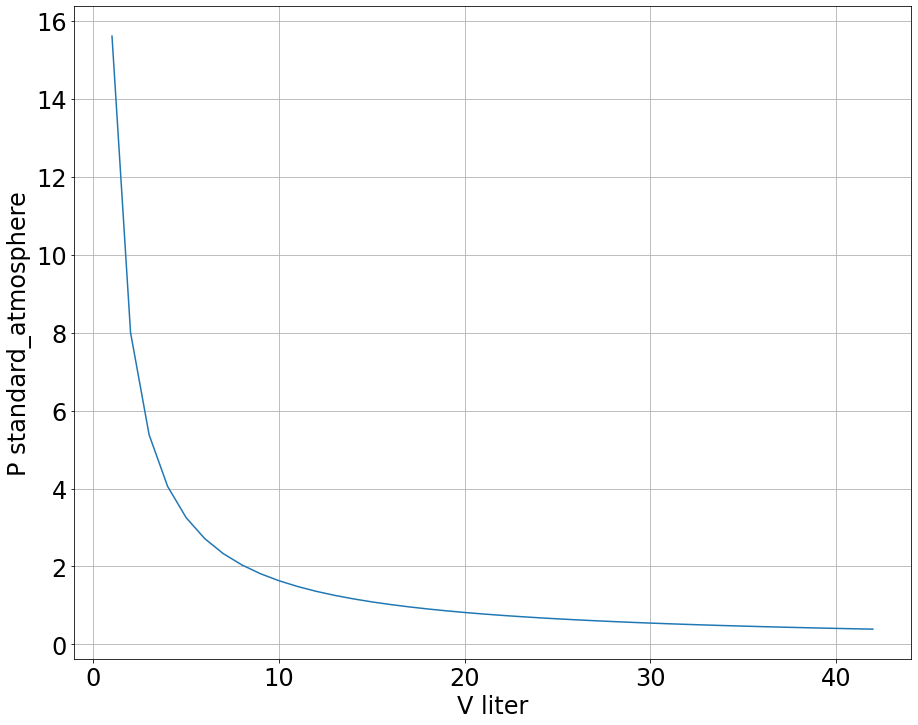

In [39]:
### BEGIN SOLUTION
Tisotherm0 = Tgrid[0,:]; print("Tisotherm = ", Tisotherm0)
Visotherm0 = Vgrid[0,:]; print("Visotherm = ", Visotherm0)
Pisotherm0 = Pgrid[0,:]; print("Pisotherm = ", Pisotherm0)

xlabel = "V "+str(Visotherm0.units)
ylabel = "P "+str(Pisotherm0.units)

plt.figure()
plt.plot(Visotherm0,Pisotherm0)
plt.grid(True)
plt.xlabel(xlabel)
plt.ylabel(ylabel)
### END SOLUTION

### Your turn (again)
In the cell below, do the following:

1. Store pressure and volume corresponding to the *last* isotherm of our gas (which is also the hottest). Name your new variables Pisothermlast and Visothermlast. Remember, the last element of a list is indexed as "-1".
1. Plot Pisothermlast as a function of the Visothermlast. Label axes appropriately.

Text(0, 0.5, 'P standard_atmosphere')

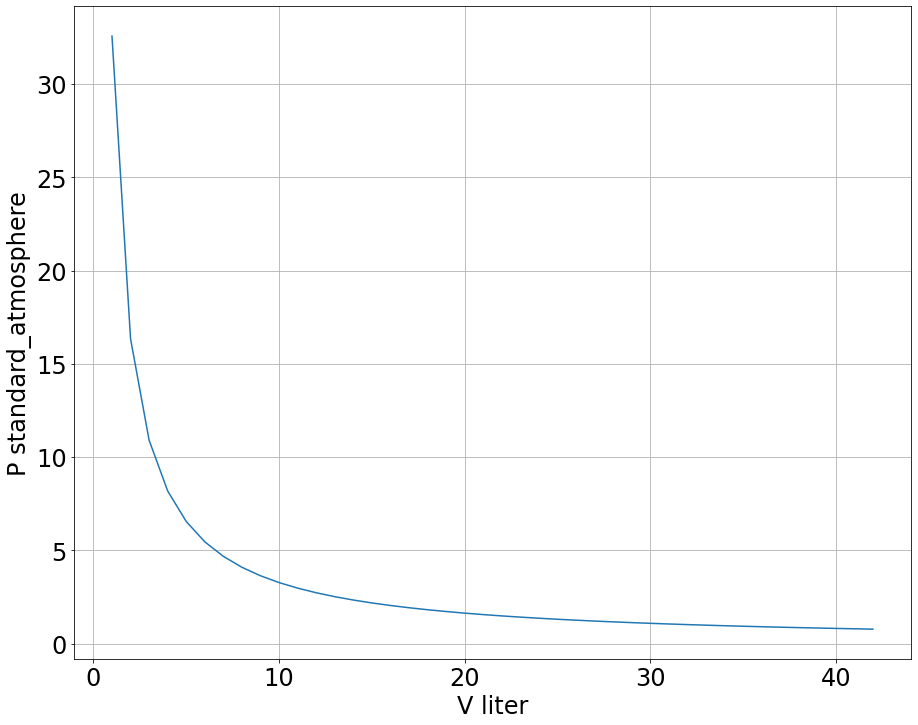

In [40]:
### BEGIN SOLUTION
Pisothermlast = Pgrid[-1,:]
Visothermlast = Vgrid[-1,:]

xlabel = "V "+str(Visothermlast.units)
ylabel = "P "+str(Pisothermlast.units)

plt.figure()
plt.plot(Visothermlast,Pisothermlast)
plt.grid(True)
plt.xlabel(xlabel)
plt.ylabel(ylabel)
### END SOLUTION

Plots such as these, in which pressure of a gas is plotted as a function of its volume, are also called *Boyle isotherms*. Check out the animation at https://en.wikipedia.org/wiki/Boyle%27s_law for a cartoon of how this is done physically.

###  Multiple isotherms on the same plot
You might have noticed how similar the first and last Boyle isotherms look -- although if you examine the graphs carefully, you'll see that the vertical scales are quite different. To compare them, it's handy to put both graphs on the same plot, and to label them using the label/legend method.

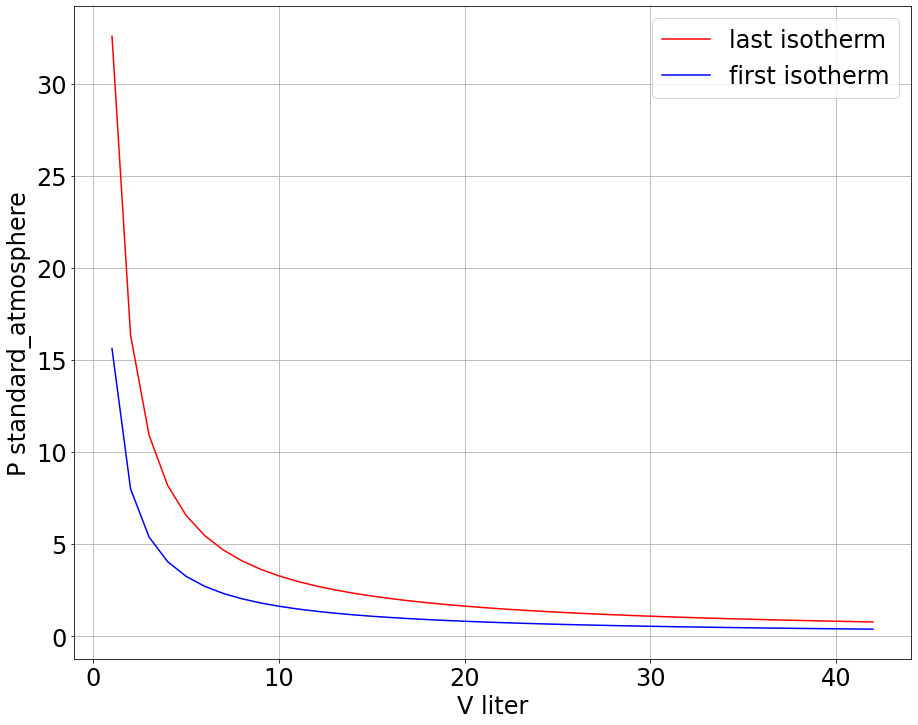

In [41]:
xlabel = "V "+str(Visothermlast.units)
ylabel = "P "+str(Pisothermlast.units)

plt.figure()
plt.plot(Visothermlast,Pisothermlast, 'red', label='last isotherm')
plt.plot(Visotherm0,Pisotherm0, 'blue', label='first isotherm')
plt.grid(True)
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.legend()

### Multiple isochores on the same plot
You've already extracted one isochore (Pisochore0 as a function of Tisochore0). Extract the last one too, then graph both on the same plot, and label them using the label/legend method. Color Pisochore0 green, and Pisochorelast pink.

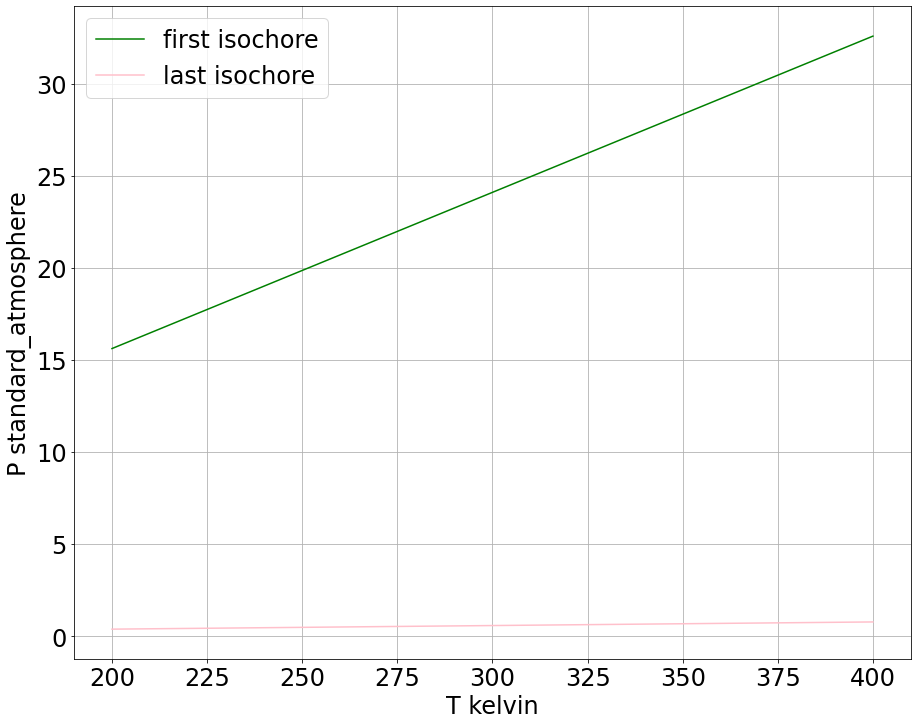

In [42]:
### BEGIN SOLUTION
Pisochorelast = Pgrid[:,-1]
Tisochorelast = Tgrid[:,-1]

xlabel = "T "+str(Tisochore0.units)
ylabel = "P "+str(Pisochore0.units)

plt.figure()
plt.plot(Tisochore0,Pisochore0,'green',label='first isochore')
plt.plot(Tisochorelast,Pisochorelast,'pink',label='last isochore')
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.grid(True)
plt.legend()
### END SOLUTION

### Your turn
In the cell below, use the same techniques to calculate and plot the numerical equivalent to $\big (\dfrac {\partial P}{\partial V} \big )_T$ as a function of the volume (shortened by one). Do this at two isotherms: the coldest and the warmest. Plot both on the same graph, and label using the label/legend method.

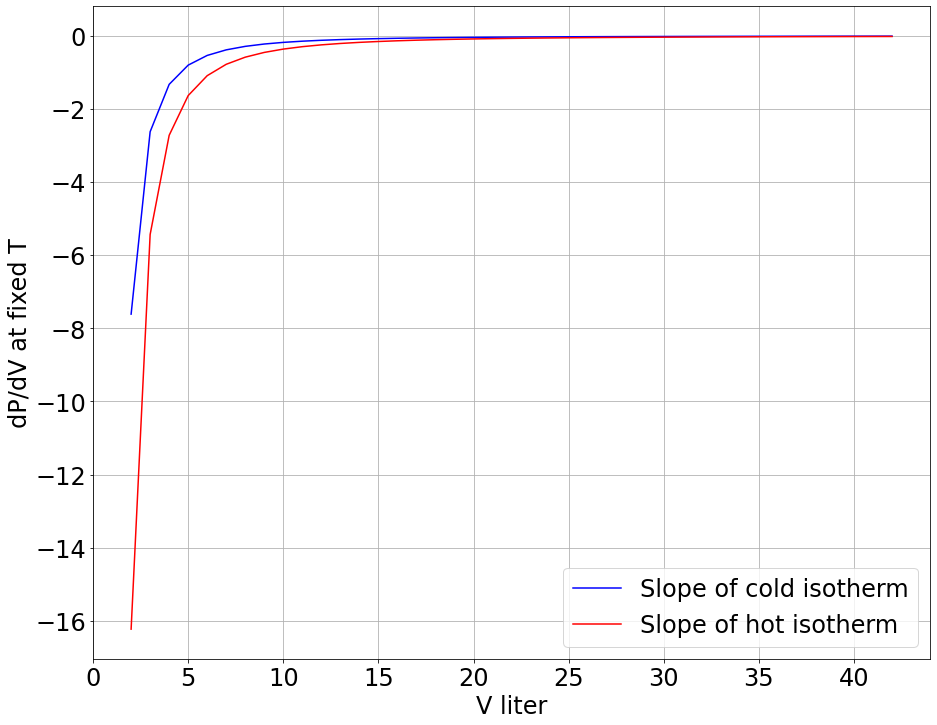

In [43]:
### BEGIN SOLUTION
xlabel = "V "+str(Visothermlast.units)
ylabel = "dP/dV at fixed T"

plt.figure()
dPdV0 = np.diff(Pisotherm0)/np.diff(Visotherm0)
plt.plot(Visotherm0[1:],dPdV0,label='Slope of cold isotherm',color='blue')
dPdVlast = np.diff(Pisothermlast)/np.diff(Visothermlast)
plt.plot(Visothermlast[1:],dPdVlast,label='Slope of hot isotherm',color='red')
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.grid(True)
plt.legend()
### END SOLUTION

### Refresh/save/validate
Almost done! To double-check everything is OK, repeat the "Three steps for refreshing and saving your code," and press the "Validate" button (as usual).

### Close/submit/logout
1. Close this notebook using the "File/Close and Halt" dropdown menu
1. Using the Assignments tab, submit this notebook
1. Press the Logout tab of the Home Page